# 06 — Loan-Level Standardised Approach RWA and Total

## Completing the Standardised Approach

This notebook completes the Standardised Approach. It multiplies each loan's post-CRM exposure by its risk weight, recognises any eligible guarantee split and then aggregates all loan results.

Total Standardised Approach Credit RWA is the first completed credit-risk denominator and later provides the aggregate output-floor benchmark.

### What the final SA calculation contains

| Term | Simple meaning |
|---|---|
| Post-CRM EAD | EAD after eligible credit risk mitigation is recognised |
| Guarantee substitution | use of the eligible guarantor's weight on the protected portion |
| RWA density | RWA divided by EAD |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


## Representative loan calculations

One performing loan from each exposure class shows EAD, risk weight and RWA. `SA RWA before guarantee` is the direct `EAD × risk weight` calculation. Final SA RWA reflects an eligible guarantee split where present.

In [2]:
sa_examples = (
    loans.loc[loans["default_flag"].eq(0)]
    .sort_values(["basel_exposure_class", "exposure_id"])
    .groupby("basel_exposure_class", as_index=False)
    .first()[["exposure_id", "basel_exposure_class", "sa_ead_post_crm", "sa_risk_weight", "sa_rwa_before_guarantee", "guaranteed_portion", "sa_rwa", "sa_rule_id"]]
)
money_columns = ["sa_ead_post_crm", "sa_rwa_before_guarantee", "guaranteed_portion", "sa_rwa"]
sa_examples[money_columns] /= CRORE
display(sa_examples.rename(columns={column: f"{column} (INR crore)" for column in money_columns}))

,exposure_id,basel_exposure_class,sa_ead_post_crm (INR crore),sa_risk_weight,sa_rwa_before_guarantee (INR crore),guaranteed_portion (INR crore),sa_rwa (INR crore),sa_rule_id
0,EXP-0027601,bank,35.361664,1.500000,53.042497,10.627189,39.227151,SA_BANK_CCC
1,EXP-0009601,corporate,335.443255,0.200000,67.088651,0.000000,67.088651,SA_CORPORATE_AAA
2,EXP-0009637,corporate_sme,426.262310,0.500000,213.131155,0.000000,213.131155,SA_CORPORATE_SME_A
3,EXP-0029401,other,0.615883,1.000000,0.615883,0.255077,0.411822,SA_FIXED_OTHER
4,EXP-0015601,regulatory_retail,0.088284,0.750000,0.066213,0.000000,0.066213,SA_FIXED_REGULATORY_RETAIL
5,EXP-0000001,residential_real_estate,0.209763,0.300000,0.062929,0.000000,0.062929,SA_MORTGAGE_OWNER_REPAYMENT_LTV_0.30
6,EXP-0021607,retail_transactor,0.004963,0.450000,0.002233,0.000000,0.002233,SA_FIXED_RETAIL_TRANSACTOR
7,EXP-0021601,revolving_retail,0.002072,0.750000,0.001554,0.000991,0.001009,SA_FIXED_REVOLVING_RETAIL
8,EXP-0028651,sovereign,43.171251,0.000000,0.000000,0.000000,0.000000,SA_SOVEREIGN_AA


When no guarantee applies, final RWA equals EAD multiplied by the borrower risk weight. A protected portion can use the eligible guarantor's weight. This changes the risk treatment without removing the legal loan exposure.

## Total Standardised Approach Credit RWA

The chart shows EAD and RWA by class. The gap reflects prescribed risk weights and recognised protection. RWA density isolates the risk intensity from the rupee size of the class.

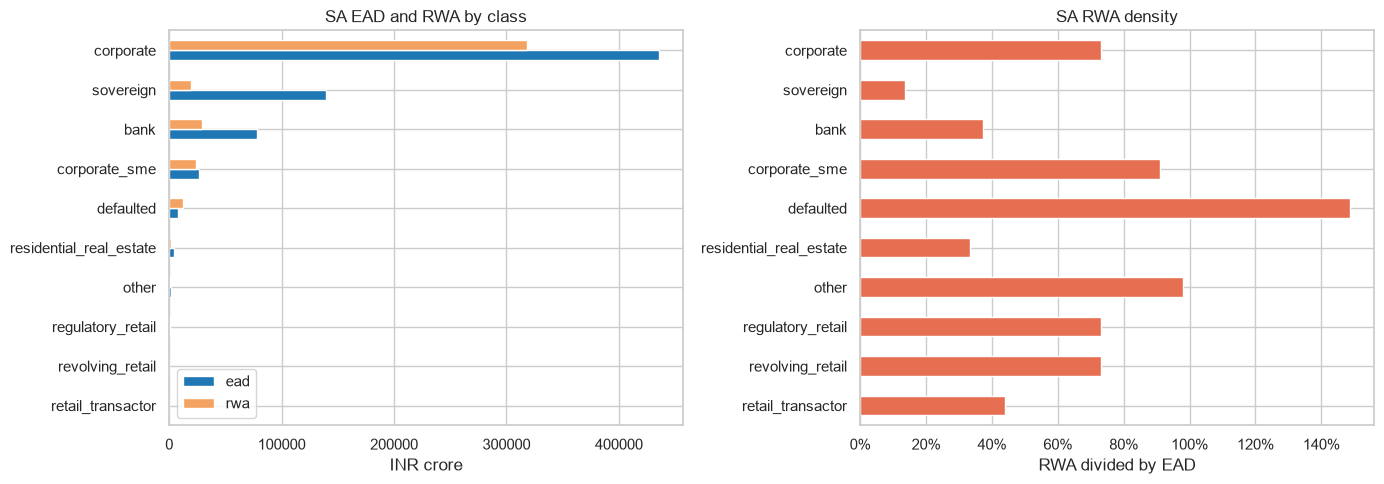

In [3]:
sa_total = loans.groupby("basel_exposure_class").agg(
    ead=("sa_ead_post_crm", "sum"),
    rwa=("sa_rwa", "sum"),
).sort_values("ead")
sa_total["rwa_density"] = sa_total["rwa"] / sa_total["ead"]
sa_total[["ead", "rwa"]] /= CRORE

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sa_total[["ead", "rwa"]].plot.barh(ax=axes[0], color=[COLORS[1], COLORS[4]], title="SA EAD and RWA by class")
sa_total["rwa_density"].plot.barh(ax=axes[1], color=COLORS[5], title="SA RWA density")
axes[0].set_xlabel("INR crore")
axes[1].set_xlabel("RWA divided by EAD")
axes[1].xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
axes[0].set_ylabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

A class can drive total RWA because it is large, because its risk weight is high, or both. The two charts distinguish these explanations.

## Loan-to-total reconciliation

The total below is the direct sum of all loan-level SA RWA values in this run. It is compared with the saved class summary to prove that aggregation did not lose or duplicate any loan.

In [4]:
loan_level_total = loans["sa_rwa"].sum()
saved_summary = pd.read_csv(ROOT / "outputs/tables/sa_summary.csv")
summary_total = saved_summary["sa_rwa"].sum()
difference = loan_level_total - summary_total

display(pd.Series({
    "Loan-level SA Credit RWA (INR crore)": loan_level_total / CRORE,
    "Class-summary SA Credit RWA (INR crore)": summary_total / CRORE,
    "Difference (INR crore)": difference / CRORE,
    "Status": "PASS" if np.isclose(difference, 0, atol=0.01) else "FAIL",
}).to_frame("Value"))
assert np.isclose(difference, 0, atol=0.01)

,Value
Loan-level SA Credit RWA (INR crore),405323.359431
Class-summary SA Credit RWA (INR crore),405323.359431
Difference (INR crore),-0.000000
Status,PASS


The PASS result completes the Standardised Approach. The IRB section begins from the same loan portfolio but develops a different risk-sensitive capital calculation.